In [1]:
import  numpy as  np  
import pandas  as pd  
df = pd.read_csv('newplacementdata - newplacementdata.csv')
df

,cgpa,placement_exam_marks,placed
0,7.19,26,1
1,7.46,38,1
2,7.54,40,1
3,6.42,8,1
4,7.23,17,0
...,...,...,...
995,8.87,44,1
996,9.12,65,1
997,4.89,34,0
998,8.62,46,1


In [2]:
df.head()

,cgpa,placement_exam_marks,placed
0,7.19,26,1
1,7.46,38,1
2,7.54,40,1
3,6.42,8,1
4,7.23,17,0


In [3]:
# odd  =  (n/2)+1 
# EVEN  = ((n/2) +  ((n/2)+1))/2
!pip install seaborn



[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import matplotlib.pyplot as  plt  
import  seaborn  as  sns  
df['placement_exam_marks'].describe()

count    1000.000000
mean       32.225000
std        19.130822
min         0.000000
25%        17.000000
50%        28.000000
75%        44.000000
max       100.000000
Name: placement_exam_marks, dtype: float64

<Axes: xlabel='placement_exam_marks'>

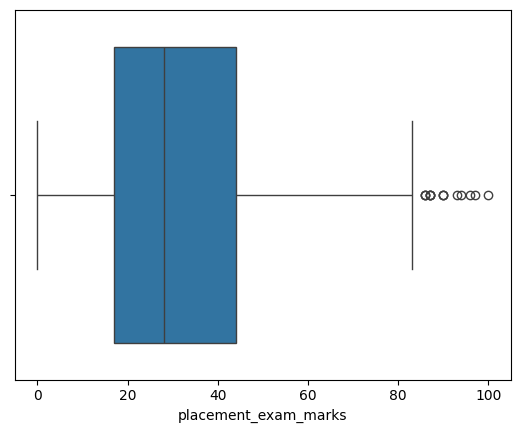

In [5]:
sns.boxplot(x=df['placement_exam_marks'])   # use  x  and y  for  horizonatl(x) and  for  vertical(y)  

In [6]:
#  finding  the  IQR :-
percentile25 = df['placement_exam_marks'].quantile(0.25)   # help  in  find  25% of  series  # quantile  is  pandas function
percentile75 = df['placement_exam_marks'].quantile(0.75)
percentile25

np.float64(17.0)

percentile75

In [7]:
# IQR
IQR = percentile75 -percentile25
IQR

np.float64(27.0)

In [8]:
upper_limit = percentile75+1.5*IQR
lower_limit = percentile25 -1.5*IQR
upper_limit

np.float64(84.5)

In [9]:
lower_limit

np.float64(-23.5)

In [10]:
#  find  out  outlier  

In [11]:
df[df['placement_exam_marks']>upper_limit]

,cgpa,placement_exam_marks,placed
9,7.75,94,1
40,6.60,86,1
61,7.51,86,0
134,6.33,93,0
162,7.80,90,0
283,7.09,87,0
290,8.38,87,0
311,6.97,87,1
324,6.64,90,0
630,6.56,96,1


In [12]:
df[df['placement_exam_marks']<lower_limit]  # df[column] > value  -> creates a Boolean mask (True / False)
                                            # df[boolean_mask]    -> uses True values to fetch actual rows
                                            # Single df = decide (logic)
                                            # Double df = deliver (data)


,cgpa,placement_exam_marks,placed


In [13]:
# trimming ---->(4 lower).......1,upper(25)........(50)-------->>>> here 1,50 are  outliers-------->
# lower(4)<<<<<--------->>>>>>upper(25) mid  data.

# capping------>>>>>>(4 lower).......1,upper(25)........(50)-------->>>>capping lower point lowest point (1)
# upper point upper point(50)------->>>>> range expand ----->>>>>. outlier remove  . 

In [14]:
# trimming(outlier removeig  technique 1)
new_df =  df[df['placement_exam_marks']<upper_limit]

In [15]:
# new_df

In [16]:
# comparision

In [17]:
plt.figure(figsize=(15,5))        # Create a new figure 
                                 #  figsize = (width, height) in inches

                                # Figure = window
                               # Subplot = grid box
                              # Plot = visualization


<Figure size 1500x500 with 0 Axes>

<Figure size 1500x500 with 0 Axes>

<Axes: xlabel='placement_exam_marks'>

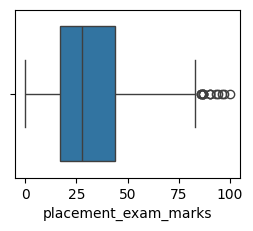

In [18]:
plt.subplot(222)    # url :- https://youtu.be/52tn54VjtDE?si=vbetwrsS3A1ct9CX
                    # also  write  in  note book  
          
                    # subplot(rows, columns, position) , position  is <=row*columns

                   # subplot(r,c) sets max slots; using all is optional
                   # NOTE: 2,2 are NOT rows/columns of data, they are grid size of the figure
                   # 2,2 shows in our code  visualization that  we  use  4  plots  ,   each  plots  use  optional  not mandatory ,  and 2,2 is not row and columns  of data  its  size  of grid(visualization window and divided in part like 2,2  mean devide  window in 4 parts)
                   # Each grid cell (subplot) contains one plot (one visualization).

                  # p :- show postion of visaulization  which  visualization  come first or sequence  of visualixation appear 
                 

sns.boxplot(x= df['placement_exam_marks'])

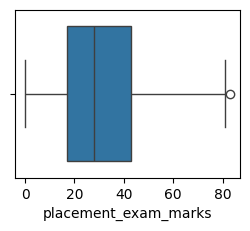

In [19]:
plt.subplot(224)
sns.boxplot(x=new_df['placement_exam_marks'])
plt.show()

In [20]:
# capping(outlier  removing  technique  2)
new_df_cap = df.copy()

In [21]:
# min =5,max=15
# min 4,3,1
# updated_min_value  = 1  
# updated_max_value  = 50 

In [25]:
new_df_cap['placement_exam_marks'] = np.where(
                                     new_df_cap['placement_exam_marks']>upper_limit,
                                     upper_limit,

                                     np.where(new_df_cap['placement_exam_marks']<lower_limit,
                                     lower_limit, 
                                     new_df_cap['placement_exam_marks']))
# np.where(condition, true_value, false_value)


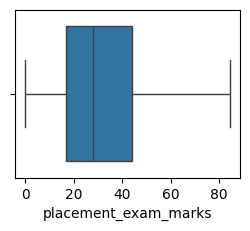

In [26]:
plt.subplot(224)
sns.boxplot(x=new_df_cap['placement_exam_marks'])
plt.show()

In [24]:
#   work or task   :
# titanic  dataset ------->>>>age------>>>>>>outlier--------->>>>>>>check
# handel  --------->>>>>>trimming,capping 


In [29]:
import  numpy as  np 
import  pandas  as  pd  

df =  pd.read_csv('titanic - titanic.csv')
df.isnull().sum()
df['Age'] = df['Age'].fillna(df['Age'].mean())
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

In [30]:
import matplotlib.pyplot as  plt
import  seaborn as  sns 
df['Age'].describe()

count    418.000000
mean      30.272590
std       12.634534
min        0.170000
25%       23.000000
50%       30.272590
75%       35.750000
max       76.000000
Name: Age, dtype: float64

<Axes: xlabel='Age'>

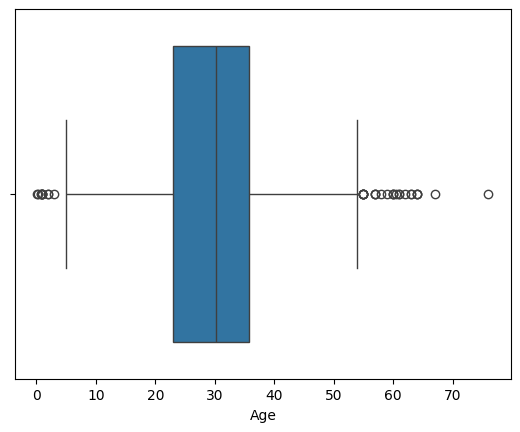

In [31]:
sns.boxplot(x=df['Age'])

In [32]:
# IQR find 
percentile_25 = df['Age'].quantile(0.25)
percentile_75 = df['Age'].quantile(0.75)
percentile_25

np.float64(23.0)

In [33]:
percentile_75 

np.float64(35.75)

In [34]:
IQR = percentile_75 - percentile_25
IQR

np.float64(12.75)

In [35]:
upper_limit =  percentile_75 + 1.5*IQR
lower_limit =  percentile_25 - 1.5*IQR
upper_limit

np.float64(54.875)

In [36]:
lower_limit

np.float64(3.875)

In [37]:
df[df['Age']>upper_limit]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
13,905,0,2,"Howard, Mr. Benjamin",male,63.0,1,0,24065,26.0000,NaN,S
20,912,0,1,"Rothschild, Mr. Martin",male,55.0,1,0,PC 17603,59.4000,NaN,C
48,940,1,1,"Bucknell, Mrs. William Robert (Emma Eliza Ward)",female,60.0,0,0,11813,76.2917,D15,C
69,961,1,1,"Fortune, Mrs. Mark (Mary McDougald)",female,60.0,1,4,19950,263.0000,C23 C25 C27,S
77,969,1,1,"Cornell, Mrs. Robert Clifford (Malvina Helen L...",female,55.0,2,0,11770,25.7000,C101,S
81,973,0,1,"Straus, Mr. Isidor",male,67.0,1,0,PC 17483,221.7792,C55 C57,S
96,988,1,1,"Cavendish, Mrs. Tyrell William (Julia Florence...",female,76.0,1,0,19877,78.8500,C46,S
114,1006,1,1,"Straus, Mrs. Isidor (Rosalie Ida Blun)",female,63.0,1,0,PC 17483,221.7792,C55 C57,S
142,1034,0,1,"Ryerson, Mr. Arthur Larned",male,61.0,1,3,PC 17608,262.3750,B57 B59 B63 B66,C


In [38]:
df[df['Age']<lower_limit]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
89,981,0,2,"Wells, Master. Ralph Lester",male,2.00,1,1,29103,23.0000,NaN,S
117,1009,1,3,"Sandstrom, Miss. Beatrice Irene",female,1.00,1,1,PP 9549,16.7000,G6,S
201,1093,0,3,"Danbom, Master. Gilbert Sigvard Emanuel",male,0.33,0,2,347080,14.4000,NaN,S
250,1142,1,2,"West, Miss. Barbara J",female,0.92,1,2,C.A. 34651,27.7500,NaN,S
263,1155,1,3,"Klasen, Miss. Gertrud Emilia",female,1.00,1,1,350405,12.1833,NaN,S
281,1173,0,3,"Peacock, Master. Alfred Edward",male,0.75,1,1,SOTON/O.Q. 3101315,13.7750,NaN,S
284,1176,1,3,"Rosblom, Miss. Salli Helena",female,2.00,1,1,370129,20.2125,NaN,S
296,1188,1,2,"Laroche, Miss. Louise",female,1.00,1,2,SC/Paris 2123,41.5792,NaN,C
307,1199,0,3,"Aks, Master. Philip Frank",male,0.83,0,1,392091,9.3500,NaN,S
354,1246,1,3,"Dean, Miss. Elizabeth Gladys Millvina""""",female,0.17,1,2,C.A. 2315,20.5750,NaN,S


In [39]:
# trimming  
new_df = df[(df['Age'] >= lower_limit) & (df['Age'] <= upper_limit)] #  under  upper   and  more  thean  lower 


<Axes: xlabel='Age'>

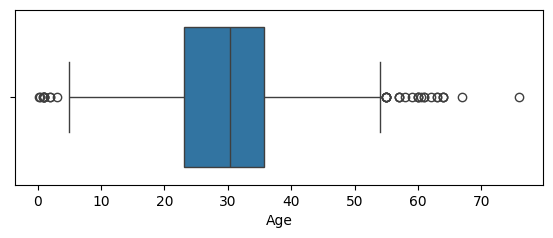

In [40]:
plt.figure(figsize = (15,5))

plt.subplot(222)

sns.boxplot(x = df['Age'])

<Axes: xlabel='Age'>

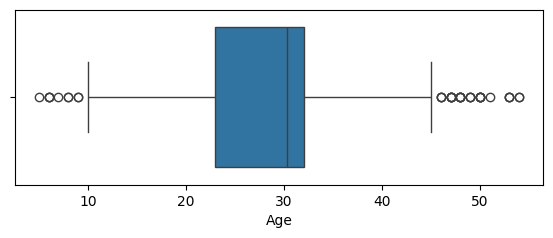

In [41]:
plt.figure(figsize = (15,5))
plt.subplot(224)
sns.boxplot(x=new_df['Age'])
#  it sow  few  outlier  after that  see  teacher  also  have  in outlier  video at  7.58 of outlier  video name 

In [42]:
#  now  use  second  method (capping):-
new_df_cap = df.copy()
new_df_cap ['Age'] = new_df_cap ['Age'].fillna(new_df_cap ['Age'].mean())
new_df_cap.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

In [43]:
new_df_cap['Age'] = np.where(new_df_cap['Age']>upper_limit,upper_limit,
            np.where(new_df_cap['Age']<lower_limit,lower_limit,new_df_cap['Age'])
                    )

<Axes: xlabel='Age'>

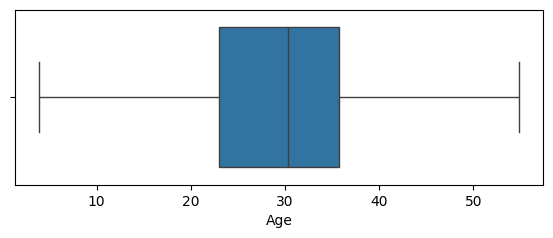

In [44]:
plt.figure(figsize = (15,5))
plt.subplot(224)
sns.boxplot(x= new_df_cap['Age'])